In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import torch

In [3]:
device = torch.device('cpu') if not torch.accelerator.is_available() else torch.accelerator.current_accelerator()
print(device)

cuda


# Hyperparameters

In [4]:
batch_size = 128
resize = (224, 224)
num_epochs = 20
lr = 0.001

# Load dataset

In [5]:
from utils.data import CIFAR10
from utils.train import train_model

def get_optimizer(model):
    return torch.optim.Adam(model.parameters(), lr=lr)

def fit(model, num_epochs=num_epochs):
    dataset = CIFAR10(batch_size=batch_size, resize=resize, device=device)
    train_dl, val_dl = dataset.get_dataloaders()
    optimizer = get_optimizer(model)
    return train_model(model, train_dl, val_dl, optimizer, num_epochs)

# Create model

In [6]:
from torch import nn

from utils.models import Module

In [7]:
class AlexNet(Module):
    def __init__(self, dropout=0.5, num_classes=10, ):
        super().__init__()
        self.dropout = dropout
        self.num_classes = num_classes
        self.net = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Flatten(),
            nn.Linear(6400, 4096), 
            nn.ReLU(),
            nn.Dropout(p=self.dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=self.dropout),
            nn.Linear(4096, self.num_classes)
        )
    
    def forward(self, X):
        return self.net(X)

In [8]:
model = AlexNet().to(device)
X = torch.randn(batch_size, 3, 224, 224).to(device)

In [9]:
with torch.no_grad():
    print(model(X).shape)

torch.Size([128, 10])


# How many parameters in model?

First conv: (3, 224, 224) -> (96, 54, 54)
* Params: 3 * 96 * 11 * 11 + 96 = 34,944

Second conv: (96, 26, 26) -> (256, 26, 26)
* Params: 96 * 256 * 5 * 5 + 256 = 614,656

Third conv: (256, 12, 12) -> (384, 12, 12)
* Params: 256 * 384 * 3 * 3 + 384 = 885,120

Fourth conv: (384, 12, 12) -> (384, 12, 12)
* Params: 384 * 384 * 3 * 3 + 384 = 1,327,488

Fifth conv: (384, 12, 12) -> (256, 12, 12)
* Params: 384 * 256 * 3 * 3 + 256 = 884,992

Linear 1: (6400) -> (4096)
* Params: 6400 * 4096 + 4096 = 26,218,496

Linear 2: (4096) -> (4096)
* Params: 4096 * 4096 + 4096 = 16,781,312

Linear 3: (4096) -> (10)
* Params: 4096 * 10 + 10 = 40970

In [10]:
# hand-calculated number of params

calculated_num_params = 34944 + 614656 + 885120 + 1327488 + 884992 + 26218496 + 16781312 + 40970
num_params = sum(p.numel() for p in model.parameters())

print(calculated_num_params, num_params)

print(f"Parameter memory: {num_params * 4 / 1e6:.0f} MB")

46787978 46787978
Parameter memory: 187 MB


# Train model

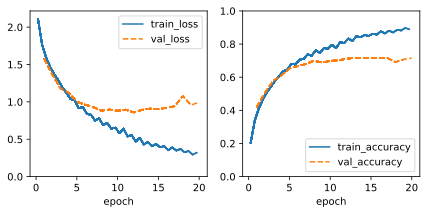

In [11]:
fit(model);

In [13]:
from utils.train import val_stats

_, val_dl = CIFAR10(batch_size=batch_size, resize=resize, device=device).get_dataloaders()
val_loss, val_accuracy = val_stats(model, val_dl, device=device)
print(f"Validation loss: {val_loss:.2f}, accuracy: {val_accuracy:.2f}")

Validation loss: 1.00, accuracy: 0.72


# How much memory usage during training?

Our dataset is 60,000 images which are reshaped to (224, 224, )

Suppose we have a batch size of 64. 

In [15]:
print(f"Max memory allocated: {torch.cuda.max_memory_allocated()/1e9:.3f} GB")

Max memory allocated: 1.457 GB
